# 02 Training

This notebook loads the processed arrays from notebook 1, builds heatmap targets, trains the radar heatmap model, and saves the best model and training history.


# Setup


In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ModuleNotFoundError:
    pass

from pathlib import Path

if Path('/content/drive/MyDrive').exists():
    PROJECT_DIR = Path('/content/drive/MyDrive/Multi-Person-Detection')
elif Path.cwd().name == 'notebooks':
    PROJECT_DIR = Path.cwd().parent
else:
    PROJECT_DIR = Path.cwd()

RAW_DATA_DIR = PROJECT_DIR / 'data' / 'raw'
PROCESSED_DIR = PROJECT_DIR / 'data' / 'processed'
MODEL_DIR = PROJECT_DIR / 'models'
EVALUATION_DIR = PROJECT_DIR / 'evaluation_results'

RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
EVALUATION_DIR.mkdir(parents=True, exist_ok=True)

print('Project directory:', PROJECT_DIR)
print('Processed data directory:', PROCESSED_DIR)
print('Model directory:', MODEL_DIR)


Mounted at /content/drive
Project directory: /content/drive/MyDrive/Multi-Person-Detection
Processed data directory: /content/drive/MyDrive/Multi-Person-Detection/data/processed
Model directory: /content/drive/MyDrive/Multi-Person-Detection/models


# Import Libraries


In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from IPython.display import display


# Configuration


In [3]:
RANDOM_STATE = 42
config_path = PROCESSED_DIR / 'preprocessing_config.json'
if not config_path.exists():
    raise FileNotFoundError(
        f'Missing preprocessing configuration: {config_path}. '
        'Run notebook 01 before training.'
    )

with open(config_path, 'r', encoding='utf-8') as f:
    preprocessing_config = json.load(f)

SEQ_LEN = int(preprocessing_config['seq_len'])
BIN_START = int(preprocessing_config['bin_start'])
BIN_END = int(preprocessing_config['bin_end'])
SELECTED_CHANNELS = list(preprocessing_config['selected_channels'])
MAX_PEOPLE = int(preprocessing_config['max_people'])
ROOM_X = float(preprocessing_config['room_x'])
ROOM_Y = float(preprocessing_config['room_y'])

FEATURE_BLOCK_KEYS = (
    'use_mag',
    'use_decluttered_mag',
    'use_motion_mag',
    'use_phase_diff',
    'use_local_variance',
)
enabled_feature_blocks = sum(
    bool(preprocessing_config[key])
    for key in FEATURE_BLOCK_KEYS
)
expected_feature_channels = len(SELECTED_CHANNELS) * enabled_feature_blocks
EXPECTED_INPUT_SHAPE = (
    SEQ_LEN,
    BIN_END - BIN_START,
    expected_feature_channels,
)

if enabled_feature_blocks == 0:
    raise ValueError('The preprocessing configuration enables no feature blocks.')
if EXPECTED_INPUT_SHAPE[1] <= 0:
    raise ValueError(f'Invalid bin range: [{BIN_START}, {BIN_END}).')

HEATMAP_H = 24
HEATMAP_W = 16
HEATMAP_SIGMA = 0.75

print('Loaded preprocessing configuration:', config_path)
print('Expected model input shape:', EXPECTED_INPUT_SHAPE)


Loaded preprocessing configuration: /content/drive/MyDrive/Multi-Person-Detection/data/processed/preprocessing_config.json
Expected model input shape: (16, 55, 24)


# Load Preprocessed Data


In [4]:
X_train = np.load(PROCESSED_DIR / 'X_train.npy')
y_coordinates_train = np.load(PROCESSED_DIR / 'y_coordinates_train.npy')
y_mask_train = np.load(PROCESSED_DIR / 'y_mask_train.npy')

X_validation = np.load(PROCESSED_DIR / 'X_validation.npy')
y_coordinates_validation = np.load(PROCESSED_DIR / 'y_coordinates_validation.npy')
y_mask_validation = np.load(PROCESSED_DIR / 'y_mask_validation.npy')


def validate_artifact_contract(split_name, X, y_coordinates, y_mask):
    """Check that loaded artifacts match the configuration saved by notebook 01."""
    expected_coordinate_shape = (len(X), MAX_PEOPLE, 2)
    expected_mask_shape = (len(X), MAX_PEOPLE)

    if X.ndim != 4 or X.shape[1:] != EXPECTED_INPUT_SHAPE:
        raise ValueError(
            f'{split_name}: expected X shape (N, {EXPECTED_INPUT_SHAPE}), '
            f'got {X.shape}. Re-run notebook 01.'
        )
    if y_coordinates.shape != expected_coordinate_shape:
        raise ValueError(
            f'{split_name}: expected coordinate shape {expected_coordinate_shape}, '
            f'got {y_coordinates.shape}. Re-run notebook 01.'
        )
    if y_mask.shape != expected_mask_shape:
        raise ValueError(
            f'{split_name}: expected mask shape {expected_mask_shape}, '
            f'got {y_mask.shape}. Re-run notebook 01.'
        )


validate_artifact_contract('train', X_train, y_coordinates_train, y_mask_train)
validate_artifact_contract('validation', X_validation, y_coordinates_validation, y_mask_validation)

print('X_train:', X_train.shape)
print('y_coordinates_train:', y_coordinates_train.shape)
print('y_mask_train:', y_mask_train.shape)
print('X_validation:', X_validation.shape)
print('y_coordinates_validation:', y_coordinates_validation.shape)
print('y_mask_validation:', y_mask_validation.shape)


X_train: (7020, 16, 55, 24)
y_coordinates_train: (7020, 4, 2)
y_mask_train: (7020, 4)
X_validation: (1872, 16, 55, 24)
y_coordinates_validation: (1872, 4, 2)
y_mask_validation: (1872, 4)


# Heatmap Targets


In [5]:
def make_heatmap_from_points(
    xy,
    mask,
    H=HEATMAP_H,
    W=HEATMAP_W,
    room_x=ROOM_X,
    room_y=ROOM_Y,
    sigma=HEATMAP_SIGMA,
):
    """
    xy:   (MAX_PEOPLE, 2)
    mask: (MAX_PEOPLE,)
    return: (H, W, 1)
    """
    heatmap = np.zeros((H, W), dtype=np.float32)

    ys = np.arange(H, dtype=np.float32)
    xs = np.arange(W, dtype=np.float32)
    yy, xx = np.meshgrid(ys, xs, indexing="ij")  # (H, W)

    for i in range(len(mask)):
        if mask[i] < 0.5:
            continue

        px, py = xy[i]

        # Labels are validated on load; clipping also protects direct calls.
        px = np.clip(px, 0.0, room_x)
        py = np.clip(py, 0.0, room_y)

        # convert meters -> heatmap pixel coordinates
        col = (px / room_x) * (W - 1)
        row = (py / room_y) * (H - 1)

        g = np.exp(-((xx - col) ** 2 + (yy - row) ** 2) / (2 * sigma ** 2))
        heatmap = np.maximum(heatmap, g)

    return heatmap[..., None]  # (H, W, 1)


def build_heatmaps(
    y_coordinates,
    y_mask,
    H=HEATMAP_H,
    W=HEATMAP_W,
    sigma=HEATMAP_SIGMA,
):
    heatmaps = [
        make_heatmap_from_points(
            y_coordinates[i],
            y_mask[i],
            H=H,
            W=W,
            room_x=ROOM_X,
            room_y=ROOM_Y,
            sigma=sigma,
        )
        for i in range(len(y_coordinates))
    ]
    return np.stack(heatmaps).astype(np.float32)


In [6]:
y_heat_train = build_heatmaps(
    y_coordinates_train,
    y_mask_train,
    H=HEATMAP_H,
    W=HEATMAP_W,
    sigma=HEATMAP_SIGMA,
)
y_heat_validation = build_heatmaps(
    y_coordinates_validation,
    y_mask_validation,
    H=HEATMAP_H,
    W=HEATMAP_W,
    sigma=HEATMAP_SIGMA,
)

print("y_heat_train     :", y_heat_train.shape)
print("y_heat_validation:", y_heat_validation.shape)


y_heat_train     : (7020, 24, 16, 1)
y_heat_validation: (1872, 24, 16, 1)


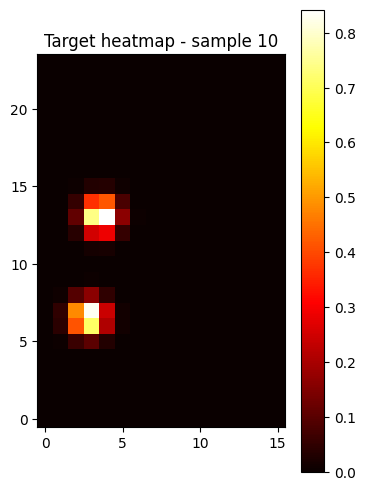

xy: [[0.8982934 2.0613527]
 [1.1434357 4.102412 ]
 [0.        0.       ]
 [0.        0.       ]]
mask: [1. 1. 0. 0.]


In [7]:
sample_idx = min(10, len(y_heat_train) - 1)

plt.figure(figsize=(4, 6))
plt.imshow(y_heat_train[sample_idx, :, :, 0], cmap='hot', origin='lower')
plt.title(f'Target heatmap - sample {sample_idx}')
plt.colorbar()
plt.show()

print('xy:', y_coordinates_train[sample_idx])
print('mask:', y_mask_train[sample_idx])


# Model and Loss

The previous U-Net-style heatmap model was accurate but too large for the assignment constraints.
This version follows the TinyML pattern used in the exercise sessions: keep the network fully convolutional, use depthwise-separable convolutions, avoid large dense layers, and downsample early enough to reduce both parameter count and activation arena usage.

The output is still a room heatmap, so the rest of the decoding and evaluation pipeline remains unchanged.


In [8]:
def tiny_sep_block(
    x,
    filters,
    kernel_size=(3, 3),
    strides=(1, 1),
    dilation_rate=(1, 1),
    name=None,
):
    """Depthwise-separable block used to keep both weights and activations small."""
    prefix = "tiny_block" if name is None else name
    x = layers.SeparableConv2D(
        filters,
        kernel_size=kernel_size,
        strides=strides,
        dilation_rate=dilation_rate,
        padding="same",
        use_bias=False,
        depthwise_initializer="he_normal",
        pointwise_initializer="he_normal",
        name=f"{prefix}_sepconv",
    )(x)
    x = layers.BatchNormalization(name=f"{prefix}_bn")(x)
    # ReLU6 is friendly to integer quantization and is common in TinyML CNNs.
    x = layers.ReLU(max_value=6.0, name=f"{prefix}_relu6")(x)
    return x


def build_tiny_radar_heatmap_model(
    input_shape,
    heatmap_h=24,
    heatmap_w=16,
    prior_prob=0.01,
):
    """Build a compact heatmap model designed for the TFLite size/arena limits."""
    inputs = keras.Input(shape=input_shape, name="radar_input")

    # The input axes are (time, range bins, feature channels). Wider kernels along
    # the range axis give the model local radar context without expensive decoder skips.
    x = tiny_sep_block(inputs, 16, kernel_size=(3, 7), name="stem_range_context")
    x = tiny_sep_block(x, 16, kernel_size=(3, 5), name="stem_refine")

    # Early range downsampling reduces the largest activation tensors, which is
    # important for the assignment activation-arena constraint.
    x = tiny_sep_block(
        x,
        24,
        kernel_size=(3, 5),
        strides=(1, 2),
        name="range_downsample",
    )
    x = tiny_sep_block(x, 24, kernel_size=(3, 3), name="range_refine")

    x = tiny_sep_block(
        x,
        32,
        kernel_size=(3, 3),
        strides=(2, 2),
        name="time_range_downsample",
    )
    x = tiny_sep_block(x, 48, kernel_size=(3, 3), name="compact_context")
    x = tiny_sep_block(
        x,
        48,
        kernel_size=(3, 3),
        dilation_rate=(2, 2),
        name="dilated_context",
    )

    # Directly resize to the room heatmap. This avoids the large U-Net decoder while
    # preserving the same output contract used by evaluation and submission code.
    x = layers.Resizing(
        heatmap_h,
        heatmap_w,
        interpolation="bilinear",
        name="resize_to_heatmap",
    )(x)
    x = tiny_sep_block(x, 32, kernel_size=(3, 3), name="heatmap_refine")
    x = tiny_sep_block(x, 16, kernel_size=(3, 3), name="heatmap_smooth")

    # Start with a low occupancy probability because most heatmap pixels are empty.
    bias_init = tf.keras.initializers.Constant(
        -np.log((1.0 - prior_prob) / prior_prob)
    )
    outputs = layers.Conv2D(
        1,
        kernel_size=1,
        padding="same",
        activation="sigmoid",
        bias_initializer=bias_init,
        name="heatmap",
    )(x)

    return keras.Model(inputs, outputs, name="tiny_radar_heatmap")


# Backward-compatible alias: downstream cells can keep the old function name.
build_radar_heatmap_unet = build_tiny_radar_heatmap_model


In [9]:
def stable_focal_dice_mass_loss(
    y_true,
    y_pred,
    alpha=0.90,
    gamma=2.0,
    dice_weight=0.3,
    mse_weight=1.0,
    mass_weight=0.20,
    center_weight=10.0,
    min_mass=5.0,
    eps=1e-6
):
    """
    Stable heatmap loss for multi-person radar/UWB heatmap prediction.

    Components:
    1. focal loss
    2. dice loss
    3. center-weighted MSE
    4. stable heatmap mass loss

    y_true: (B, H, W, 1)
    y_pred: (B, H, W, 1)
    """

    y_pred = tf.clip_by_value(y_pred, eps, 1.0 - eps)

    # =====================================================
    # 1. Focal loss
    # =====================================================
    bce = -(
        y_true * tf.math.log(y_pred)
        + (1.0 - y_true) * tf.math.log(1.0 - y_pred)
    )

    p_t = y_true * y_pred + (1.0 - y_true) * (1.0 - y_pred)
    alpha_t = y_true * alpha + (1.0 - y_true) * (1.0 - alpha)

    focal = alpha_t * tf.pow(1.0 - p_t, gamma) * bce
    focal = tf.reduce_mean(focal)

    # =====================================================
    # 2. Dice loss
    # =====================================================
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    union = tf.reduce_sum(y_true + y_pred, axis=[1, 2, 3])

    dice = 1.0 - tf.reduce_mean(
        (2.0 * intersection + eps) / (union + eps)
    )

    # =====================================================
    # 3. Center-weighted MSE
    # =====================================================
    weights = 1.0 + center_weight * y_true
    center_mse = tf.reduce_mean(
        weights * tf.square(y_true - y_pred)
    )

    # =====================================================
    # 4. Stable mass loss
    # =====================================================
    true_mass = tf.reduce_sum(y_true, axis=[1, 2, 3])
    pred_mass = tf.reduce_sum(y_pred, axis=[1, 2, 3])

    # Avoid division by very small true_mass
    denom = tf.maximum(true_mass, min_mass)

    # Smooth relative error instead of raw squared relative error
    mass_error = (pred_mass - true_mass) / denom

    # Clip to avoid exploding gradients
    mass_error = tf.clip_by_value(mass_error, -5.0, 5.0)

    mass_loss = tf.reduce_mean(tf.square(mass_error))

    total_loss = (
        focal
        + dice_weight * dice
        + mse_weight * center_mse
        + mass_weight * mass_loss
    )

    return total_loss


# Build Model


In [10]:
model = build_tiny_radar_heatmap_model(
    input_shape=X_train.shape[1:],
    heatmap_h=HEATMAP_H,
    heatmap_w=HEATMAP_W,
)

model.summary()
print(f"Trainable parameters: {model.count_params():,}")


Model: "tiny_radar_heatmap"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ radar_input (InputLayer)        │ (None, 16, 55, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_range_context_sepconv      │ (None, 16, 55, 16)     │           888 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_range_context_bn           │ (None, 16, 55, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_range_context_relu6 (ReLU) │ (None, 16, 55, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_refine_sepconv             │ (None, 16, 55, 16)     │           496 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_refine_bn                  │ (None, 16, 55, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_refine_relu6 (ReLU)        │ (None, 16, 55, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ range_downsample_sepconv        │ (None, 16, 28, 24)     │           624 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ range_downsample_bn             │ (None, 16, 28, 24)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ range_downsample_relu6 (ReLU)   │ (None, 16, 28, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ range_refine_sepconv            │ (None, 16, 28, 24)     │           792 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ range_refine_bn                 │ (None, 16, 28, 24)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ range_refine_relu6 (ReLU)       │ (None, 16, 28, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_range_downsample_sepconv   │ (None, 8, 14, 32)      │           984 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_range_downsample_bn        │ (None, 8, 14, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_range_downsample_relu6     │ (None, 8, 14, 32)      │             0 │
│ (ReLU)                          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ compact_context_sepconv         │ (None, 8, 14, 48)      │         1,824 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ compact_context_bn              │ (None, 8, 14, 48)      │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 12,153 (47.47 KB)

 Trainable params: 11,641 (45.47 KB)

 Non-trainable params: 512 (2.00 KB)

Trainable parameters: 12,153


In [11]:
BATCH_SIZE = 64
EPOCHS = 100
# The compact model has fewer parameters, so a slightly larger learning rate helps it converge.
LEARNING_RATE = 3e-4

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=stable_focal_dice_mass_loss,
    metrics=["mae"]
)


# Model Training


In [12]:
best_model_path = MODEL_DIR / 'best_heatmap_model.keras'
final_model_path = MODEL_DIR / 'final_heatmap_model_best_weights.keras'

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        mode="min",
        verbose=1
    ),

    keras.callbacks.ModelCheckpoint(
        filepath=str(best_model_path),
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    )
]

history = model.fit(
    X_train,
    y_heat_train,
    validation_data=(X_validation, y_heat_validation),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    shuffle=True,
    callbacks=callbacks
)


Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 0.4286 - mae: 0.0378
Epoch 1: val_loss improved from None to 0.45799, saving model to /content/drive/MyDrive/Multi-Person-Detection/models/best_heatmap_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Multi-Person-Detection/models/best_heatmap_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 49s 237ms/step - loss: 0.4108 - mae: 0.0376 - val_loss: 0.4580 - val_mae: 0.0309 - learning_rate: 3.0000e-04
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3932 - mae: 0.0376
Epoch 2: val_loss did not improve from 0.45799
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.3921 - mae: 0.0375 - val_loss: 0.4585 - val_mae: 0.0306 - learning_rate: 3.0000e-04
Epoch 3/100
108/110 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3882 - mae: 0.0371
Epoch 3: val_loss did not improve from 0.45799
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.3875 - mae: 0.0371 - val_loss: 0.4659 - val_mae: 0.0292 - learning_rate: 3.

In [13]:
model.save(final_model_path)
print('Saved best model:', best_model_path)
print('Saved final model:', final_model_path)


Saved best model: /content/drive/MyDrive/Multi-Person-Detection/models/best_heatmap_model.keras
Saved final model: /content/drive/MyDrive/Multi-Person-Detection/models/final_heatmap_model_best_weights.keras


# Training History


,loss,mae,val_loss,val_mae,learning_rate
26,0.324225,0.029959,0.395110,0.028994,0.000038
27,0.323404,0.029834,0.392815,0.029184,0.000038
28,0.323142,0.029824,0.393014,0.029325,0.000038
29,0.322257,0.029799,0.392976,0.029150,0.000019
30,0.322570,0.029811,0.393909,0.029109,0.000019


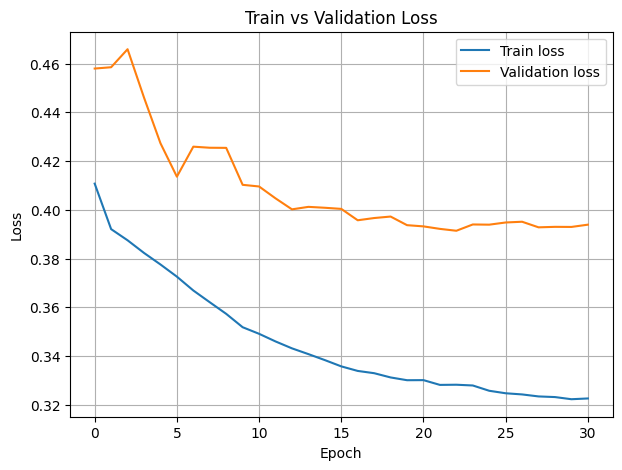

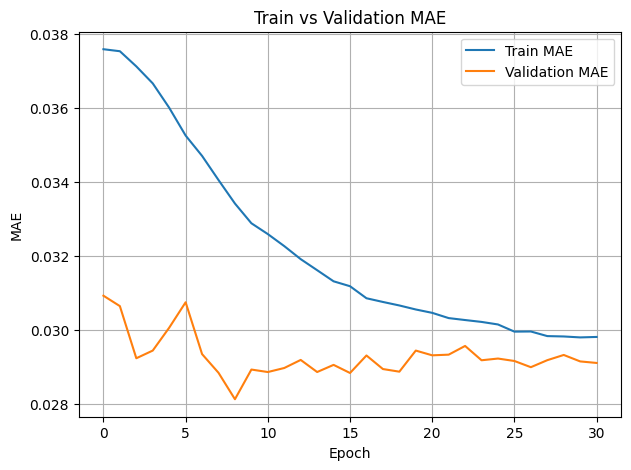

In [14]:
history_df = pd.DataFrame(history.history)
history_df.to_csv(MODEL_DIR / 'training_history.csv', index=False)
np.savez(MODEL_DIR / 'training_history.npz', **history.history)

display(history_df.tail())

import matplotlib.pyplot as plt

def plot_training_curves(history):
    hist = history.history

    plt.figure(figsize=(7, 5))
    plt.plot(hist["loss"], label="Train loss")
    plt.plot(hist["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Train vs Validation Loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    if "mae" in hist and "val_mae" in hist:
        plt.figure(figsize=(7, 5))
        plt.plot(hist["mae"], label="Train MAE")
        plt.plot(hist["val_mae"], label="Validation MAE")
        plt.xlabel("Epoch")
        plt.ylabel("MAE")
        plt.title("Train vs Validation MAE")
        plt.grid(True)
        plt.legend()
        plt.show()


plot_training_curves(history)


# Quick Validation Predictions


30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step
y_pred_validation shape: (1872, 24, 16, 1)
y_heat_validation shape: (1872, 24, 16, 1)


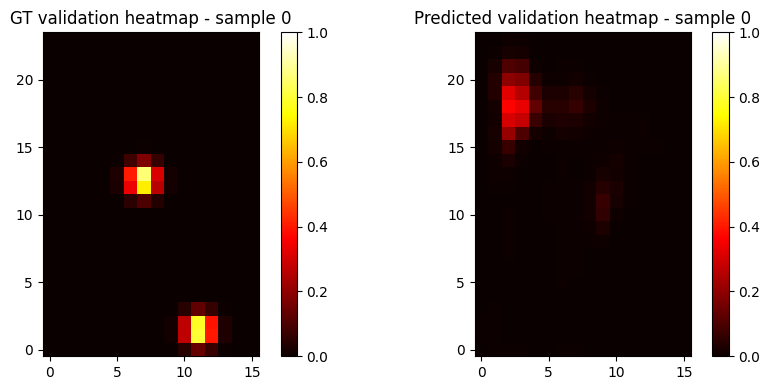

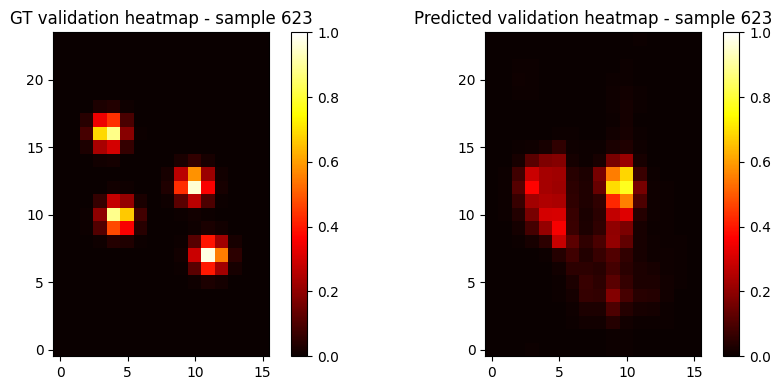

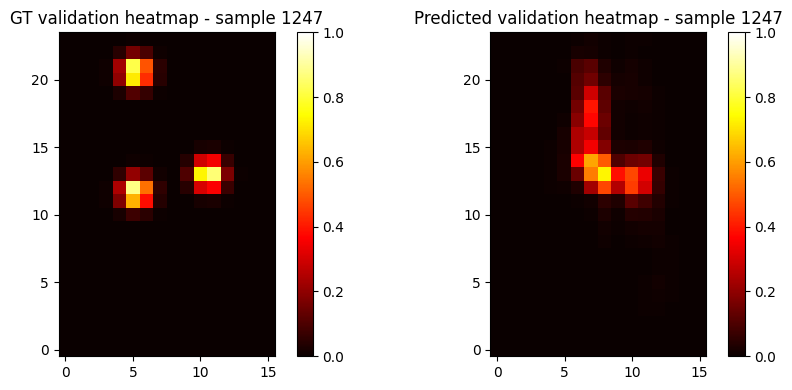

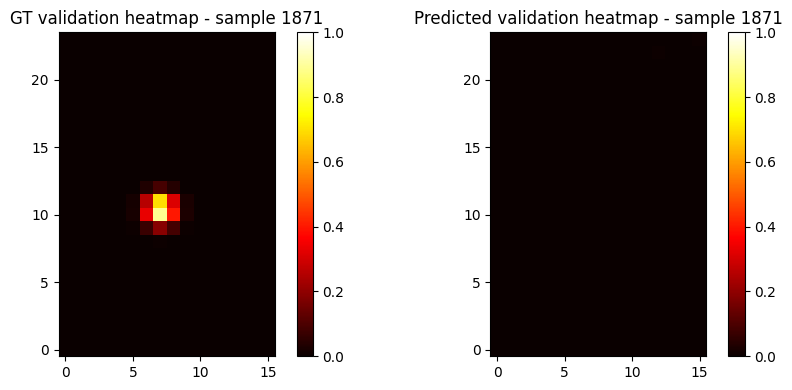

In [15]:
y_pred_validation = model.predict(X_validation, batch_size=BATCH_SIZE)

print('y_pred_validation shape:', y_pred_validation.shape)
print('y_heat_validation shape:', y_heat_validation.shape)

for idx in np.linspace(0, len(y_pred_validation) - 1, min(4, len(y_pred_validation)), dtype=int):
    plt.figure(figsize=(9, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(y_heat_validation[idx, :, :, 0], origin='lower', cmap='hot', vmin=0, vmax=1)
    plt.title(f'GT validation heatmap - sample {idx}')
    plt.colorbar()

    plt.subplot(1, 2, 2)
    plt.imshow(y_pred_validation[idx, :, :, 0], origin='lower', cmap='hot', vmin=0, vmax=1)
    plt.title(f'Predicted validation heatmap - sample {idx}')
    plt.colorbar()

    plt.tight_layout()
    plt.show()
